**Download the dataset from scikit-learn:  IRIS Dataset**

In [33]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


**Use K-means clustering to cluster this data into 2,3,4 and 5 clusters.**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# assign X and Y
X = iris.data
y = iris.target

**explanation**
- assign feature and target for the iris dataset

In [4]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**explanation**
- scaling required for kmeans

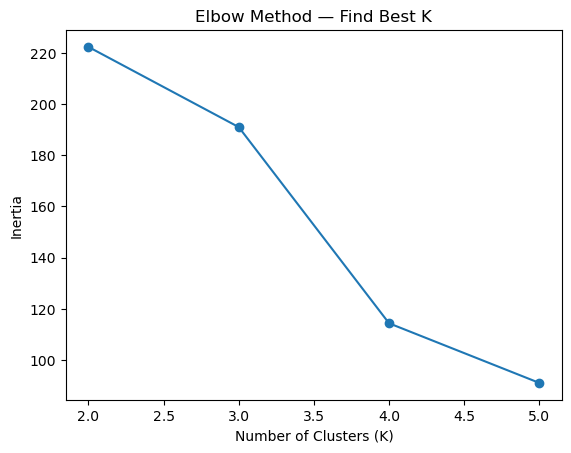

In [10]:
# elbow method
k_values = [2, 3, 4, 5]
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Find Best K")
plt.show()

**explanation**
- using the elbow method, the bend (elbow) happens at K=4 which indicates the best choice for K with this method
- The elbow isn't exactly sharp and seems to happen between 3-4. Will use other methods to determine the best K

In [11]:
#Davies Bouldin Score
from sklearn.metrics import davies_bouldin_score

k_values = [2, 3, 4, 5]
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    db = davies_bouldin_score(X_scaled, labels)
    db_scores.append(db)

# Print results
for i, k in enumerate(k_values):
    print(f"K = {k}, Davies-Bouldin Score = {db_scores[i]:.3f}")

K = 2, Davies-Bouldin Score = 0.593
K = 3, Davies-Bouldin Score = 0.789
K = 4, Davies-Bouldin Score = 0.870
K = 5, Davies-Bouldin Score = 0.944


**explanation**
- Davies Bouldin Score measures how good the clusters are. The lowest score being 2, this is where the clusters are tight and well separated.

In [12]:
# Silhouette Coefficient 
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5]
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Print results
for i, k in enumerate(k_values):
    print(f"K = {k}, Silhouette Score = {sil_scores[i]:.3f}")

K = 2, Silhouette Score = 0.582
K = 3, Silhouette Score = 0.480
K = 4, Silhouette Score = 0.385
K = 5, Silhouette Score = 0.345


**overall comparison**

- The Silhouette score measures how well the points fit into the clusters. The result shows K=2 being the best choice here. The higher the score, the better it fits
- The 3 final results:
  1. Elbow method: K=4
  2. Davies Bouldin Score: K=2
  3. Silhuoete score: K=2

- According to ChatGPT, the results for the 3 methods differ since they answer different questions. Elbow method focuses on reducing errors, Davis Bouldin focuses on separation, and Silhouette focuses on Tightness and seperation.
- The iris dataset has 3 groups, 2 of the groups overlap leading to Davies Bouldn and Silhouette favoring K=2.
- The best choice would be K=3 in this case which lies between the results.

**In the study notes, you have learned how to implement your own PCA algorithm to reduce the dimensionality of a dataset. In this exercise, you are supposed to perform dimensionality reduction on the iris data set (from 4 to 2) using the Scikit learns implementation of PCA.**

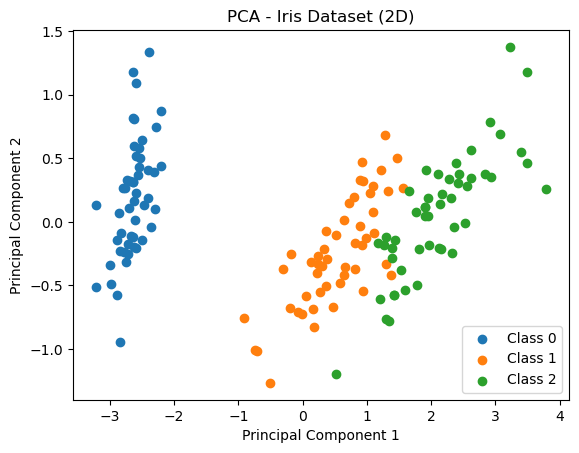

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Scatter Plot after PCA
plt.figure()
for i in range(3):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=f"Class {i}")

plt.title("PCA - Iris Dataset (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

**explanation**

- `n_components = 2` reduces the dimension to 2. Iris dataset feature had 4 features, performing reduction based on the quesiton to 2 features.
- X_pca has a new shape of (150,2) instead of (150, 4)
- in scatter plot, it's looped through range 3 since the dataset has 3 targets.
- I had trouble plotting the points for each class, but with ChatGPT's help, I was able to plot the points one at a time. `y==i` allows the plot to only select the class its in.


After PCA, the Iris data is reduced from 4D to 2D, which makes it easier to visualize.
If the classes separate well in the scatter plot, it means PCA preserved useful structure in the data.

**Implement SVM, Naïve Bayes and Logistic Regression algorithms to perform classification on IRIS Dataset. Provide Results, Accuracy Score of Prediction and Visualization.**

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# split data
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**explanation**

- split data into training and testing sets
- 20% testing, 80% training

In [26]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

models = [
    ("SVM", SVC()),
    ("Naive Bayes", GaussianNB()),
    ("Logistic Regression", LogisticRegression())
]

results = []
for name, model in models:
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    results.append({"Model": name, "Avg accuracy": scores.mean(), "Std Dev": scores.std()})

df_results = pd.DataFrame(results).sort_values("Avg accuracy", ascending=False)
print(df_results)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Avg accuracy   Std Dev
2  Logistic Regression      0.973333  0.024944
0                  SVM      0.966667  0.021082
1          Naive Bayes      0.953333  0.026667


**explanation**

- starting by creating a list for the models and renaming them
- created an empty list for results
- loop through each model and add the mean, and std of the score
- print results in order

- according to the results, logistic regression has the highest accuracy, but all models have relative high scores, all performing well.

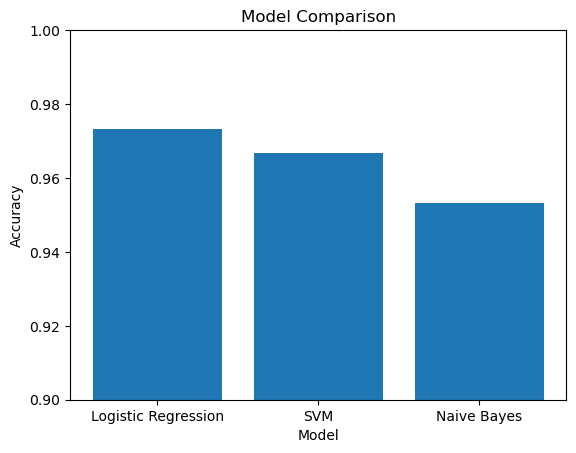

In [28]:
plt.figure()
plt.bar(df_results["Model"], df_results["Avg accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.90, 1.00)
plt.show()

**explanation**

- plotting a simple bar chart to compare the 3 model results

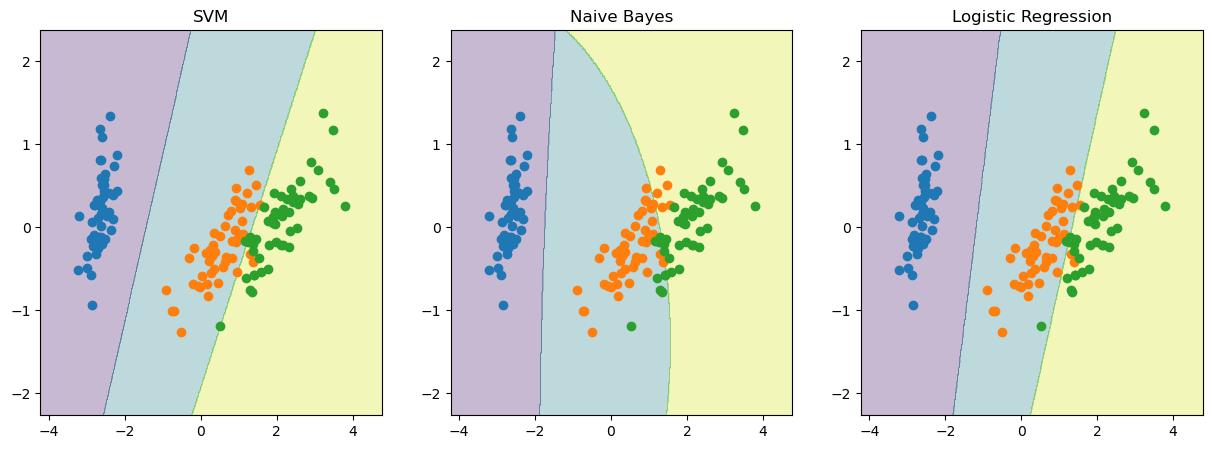

In [35]:
# plots
models = [
    ("SVM", SVC(kernel='linear')),
    ("Naive Bayes", GaussianNB()),
    ("Logistic Regression", LogisticRegression())
]

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models):
    model.fit(X_pca, y)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 3, i+1)
    plt.contourf(xx, yy, Z, alpha=0.3)

    for j in range(3):
        plt.scatter(X_pca[y == j, 0], X_pca[y == j, 1])

    plt.title(name)

plt.show()

**explanation**

- The plots help visualize how well each model separates the classes
- starting by listing out all the models in a list with their names
- setting figure size, at first I plotted all of them separately, but decided to combine for cleaner look
- loop through the list of models to plot them
- all the settings are the same for each plot:
  - contourf draws the color for each zone
  - plt.scatter plots the scatterplot
  - labeled each plto by their model names

- as the plot shows:
  - SVM has a slight overlap between 2 classes
  - Naive Bayes has a more flexible boundary, but overlapping region is confusing
  - Logistic Regression is very similar to SVM. it creates linear boundaries, slight overlap between 2 classes.
  - it shows purple class being easy to separate, and the other 2 class overlapping, which is the same as the results mentioned earlier.